# EDA — Drone Telemetry Cyberattack Dataset

Dataset: merged PX4 SITL flight logs (`raw_dataset.csv`) — Normal / Ping DoS / GPS Spoofing, across multiple airframes.

Covers: missing values, duplicate rows, data types, feature distributions, attack class balance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("../dataset/raw_dataset.csv")
print(df.shape)
df.head()

(75573, 22)


,timestamp,altitude,jamming_indicator,satellites_used,eph,epv,latitude,longitude,battery,speed,roll,pitch,yaw,link_data_rate,packet_errors,heartbeat_time,heartbeat_gap,packet_seq,attack_type,is_attack,airframe,flight_id
0,0,0,0,0,655.35,655.35,0.0,0.0,100.0,0.000929,-1.212548,-1.124664,99.521061,4000.0,0.0,0.0,0.0,0,Normal,0,PX4-H480-SITL,log_12_2020-8-2-14-18-24
1,4000,0,0,0,655.35,655.35,0.0,0.0,100.0,0.000929,-1.212548,-1.124664,99.521061,4000.0,0.0,0.0,4000.0,1,Normal,0,PX4-H480-SITL,log_12_2020-8-2-14-18-24
2,16000,0,0,0,655.35,655.35,0.0,0.0,100.0,0.000929,-1.212548,-1.124664,99.521061,4000.0,0.0,0.0,16000.0,2,Normal,0,PX4-H480-SITL,log_12_2020-8-2-14-18-24
3,16000,0,0,0,655.35,655.35,0.0,0.0,100.0,0.000929,-1.212548,-1.124664,99.521061,4000.0,0.0,0.0,16000.0,3,Normal,0,PX4-H480-SITL,log_12_2020-8-2-14-18-24
4,16000,0,0,0,655.35,655.35,0.0,0.0,100.0,0.000929,-1.212548,-1.124664,99.521061,4000.0,0.0,0.0,16000.0,4,Normal,0,PX4-H480-SITL,log_12_2020-8-2-14-18-24


## 1. Data types

In [2]:
df.dtypes

timestamp              int64
altitude               int64
jamming_indicator      int64
satellites_used        int64
eph                  float64
epv                  float64
latitude             float64
longitude            float64
battery              float64
speed                float64
roll                 float64
pitch                float64
yaw                  float64
link_data_rate       float64
packet_errors        float64
heartbeat_time       float64
heartbeat_gap        float64
packet_seq             int64
attack_type           object
is_attack              int64
airframe              object
flight_id             object
dtype: object

## 2. Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_summary

,missing_count,missing_pct
roll,17447,23.09
pitch,17447,23.09
yaw,17447,23.09
speed,10221,13.52
link_data_rate,3099,4.10
packet_errors,3099,4.10
heartbeat_time,3099,4.10
heartbeat_gap,3099,4.10


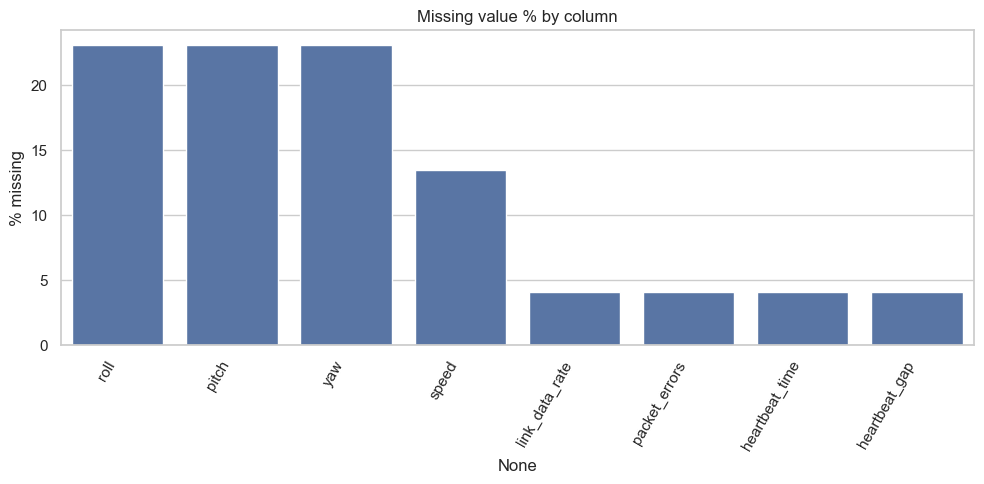

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("% missing")
plt.title("Missing value % by column")
plt.tight_layout()
plt.show()

## 3. Duplicate rows

In [5]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicate rows: {dupe_count}")

# Also check duplicates within a flight on timestamp (shouldn't happen after merge_asof)
dupe_ts = df.duplicated(subset=["flight_id", "timestamp"]).sum()
print(f"Duplicate (flight_id, timestamp) pairs: {dupe_ts}")

Fully duplicate rows: 0
Duplicate (flight_id, timestamp) pairs: 47


## 4. Attack class distribution

attack_type
Ping DoS        28647
Normal          23760
GPS Spoofing    23166
Name: count, dtype: int64


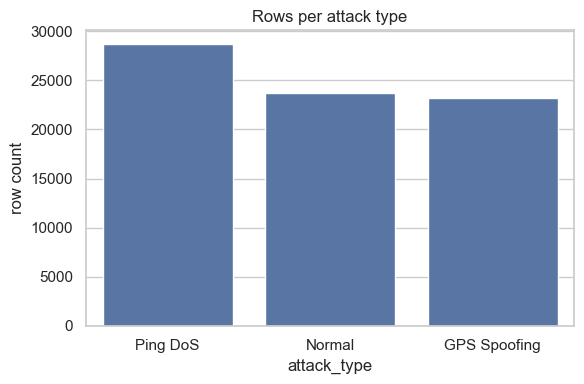

In [6]:
counts = df["attack_type"].value_counts()
print(counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.ylabel("row count")
plt.title("Rows per attack type")
plt.tight_layout()
plt.show()

In [7]:
# Class balance per flight (some flights might be much longer than others,
# skewing row-level balance even if flight-level balance looks fine)
flight_summary = df.groupby(["airframe", "attack_type", "flight_id"]).size().reset_index(name="rows")
flight_summary.sort_values(["attack_type", "rows"])

,airframe,attack_type,flight_id,rows
10,PX4-TAIL-SITL,GPS Spoofing,log_9_2020-8-2-15-07-29,2560
13,PX4-VTOL-SITL,GPS Spoofing,log_13_2020-8-2-15-42-58,2616
2,PX4-PLANE-SITL,GPS Spoofing,log_7_2020-8-2-20-07-58,3286
5,PX4-QUAD-HITL,GPS Spoofing,log_46_2020-8-2-19-18-26,7122
7,PX4-QUAD-SITL,GPS Spoofing,log_0_2020-8-2-10-39-13,7582
14,PX4-VTOL-SITL,Normal,log_15_2020-8-2-15-29-20,2196
11,PX4-TAIL-SITL,Normal,log_8_2020-8-2-14-56-47,2232
3,PX4-PLANE-SITL,Normal,log_2_2020-8-2-19-54-17,5125
0,PX4-H480-SITL,Normal,log_12_2020-8-2-14-18-24,6963
8,PX4-QUAD-SITL,Normal,log_6_2020-8-1-21-26-31,7244


## 5. Feature distributions

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ["timestamp", "is_attack", "packet_seq"]
numeric_cols = [c for c in numeric_cols if c not in exclude]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
altitude,75573.0,9.569217e+04,1.395701e+04,0.000000,9.990100e+04,1.000510e+05,1.001550e+05,1.088910e+05
jamming_indicator,75573.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
satellites_used,75573.0,9.954349e+00,6.741174e-01,0.000000,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+01
eph,75573.0,3.987188e+00,4.411087e+01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,6.553500e+02
epv,75573.0,3.987188e+00,4.411087e+01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,6.553500e+02
latitude,75573.0,4.375012e+01,2.963323e+00,0.000000,4.394440e+01,4.394516e+01,4.394619e+01,4.452025e+01
longitude,75573.0,-7.853169e+01,5.318531e+00,-78.901894,-7.889840e+01,-7.889720e+01,-7.889646e+01,0.000000e+00
battery,75573.0,4.809724e+01,1.896771e+01,0.000000,5.000215e+01,5.000215e+01,5.000215e+01,1.000000e+02
speed,65352.0,7.028997e+00,5.377900e+00,0.000632,4.432753e+00,4.971740e+00,1.352263e+01,2.334497e+01
roll,58126.0,1.005094e+00,2.278965e+01,-130.990805,-2.259594e-01,2.094433e+00,2.844188e+00,9.512034e+01


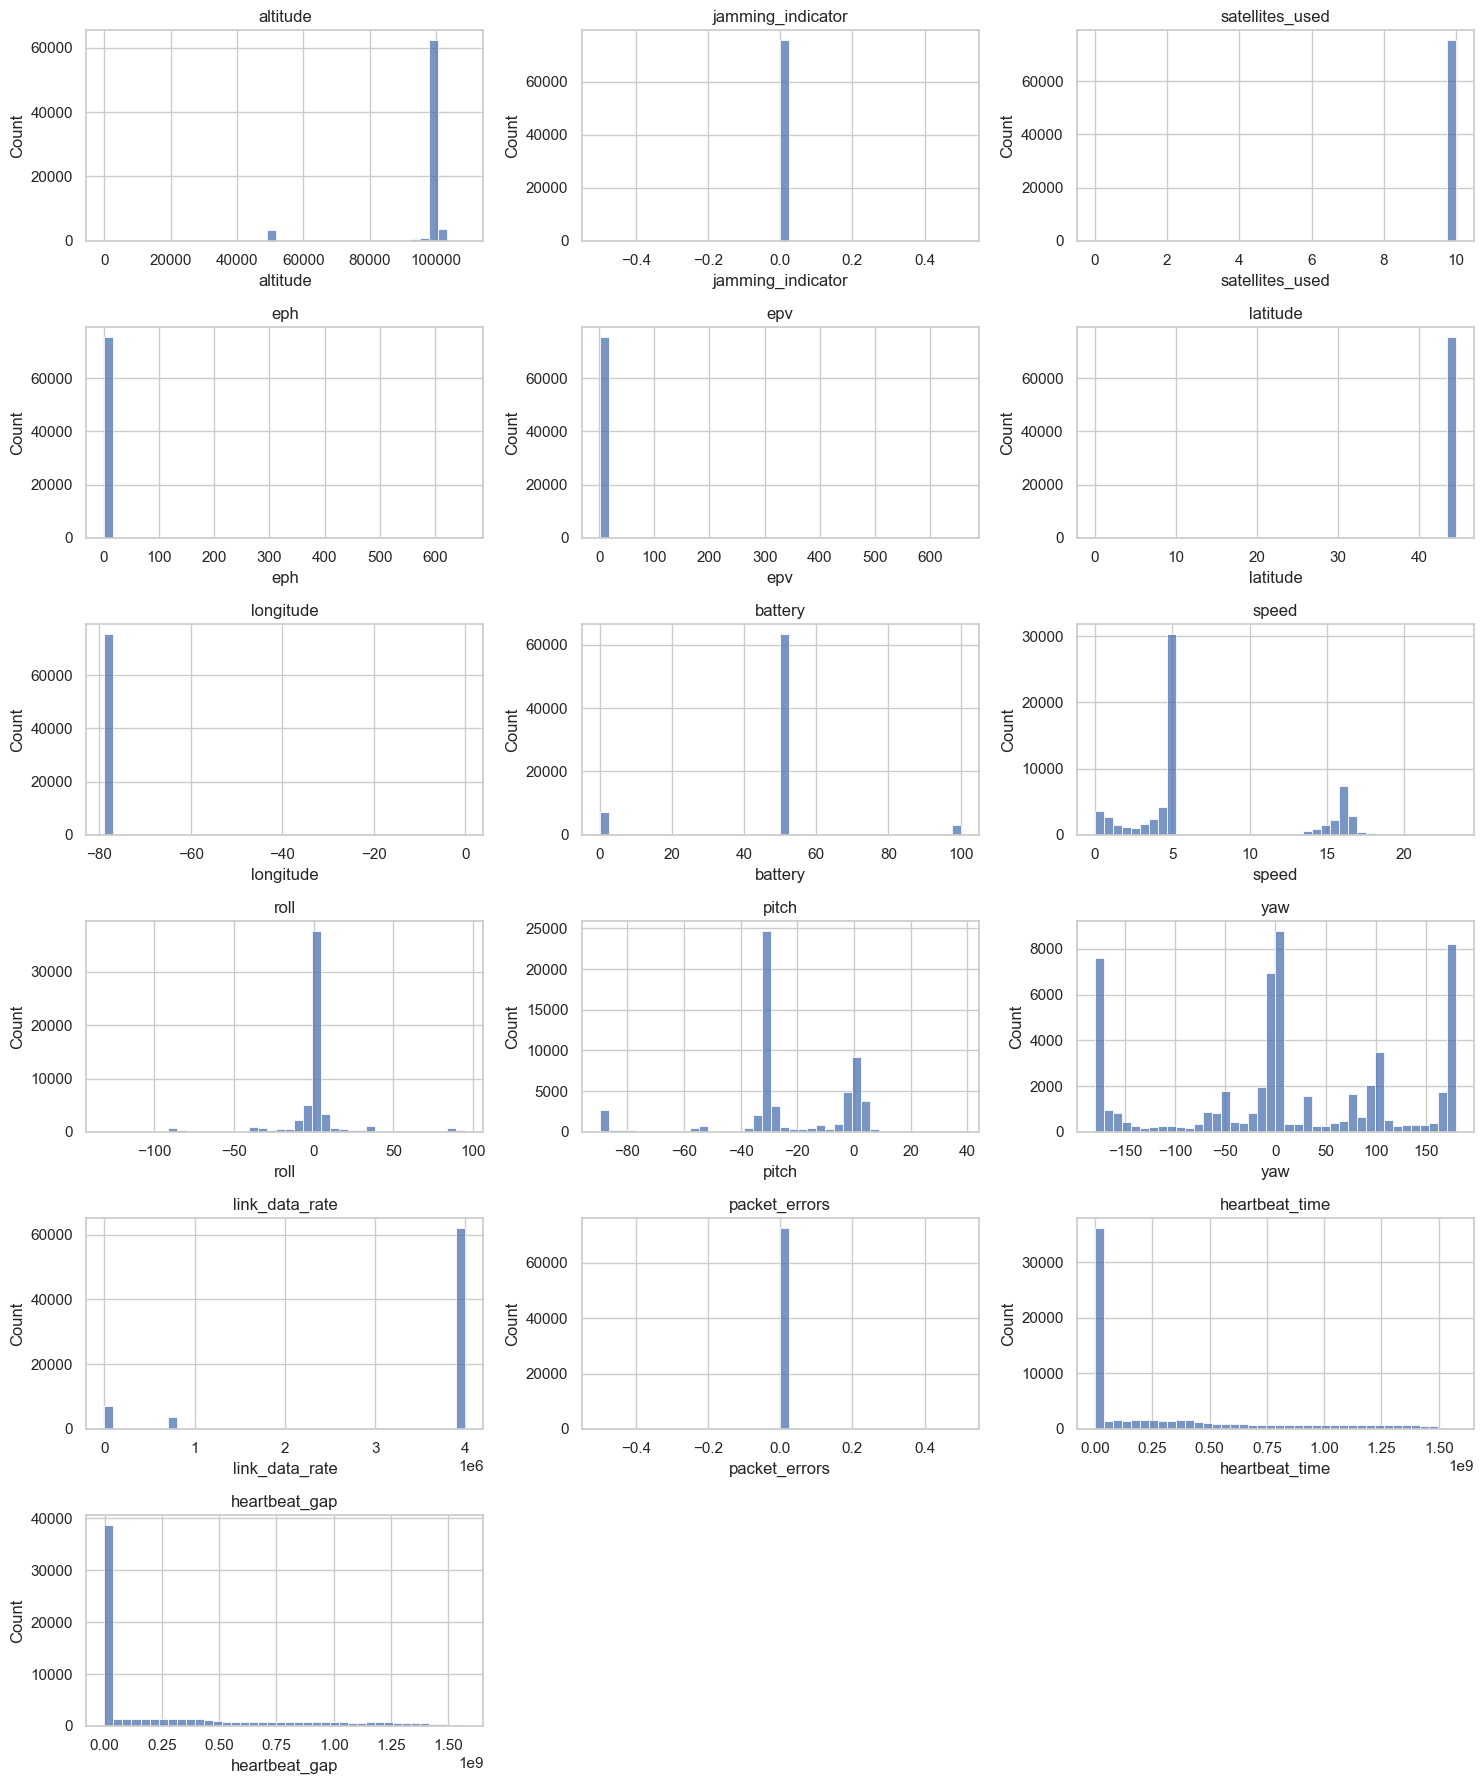

In [9]:
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], kde=False)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Feature distributions split by attack type\n\nThis is the key check — do Normal / Ping DoS / GPS Spoofing rows actually look different? If a feature shows no separation across classes, it likely won't help the model.

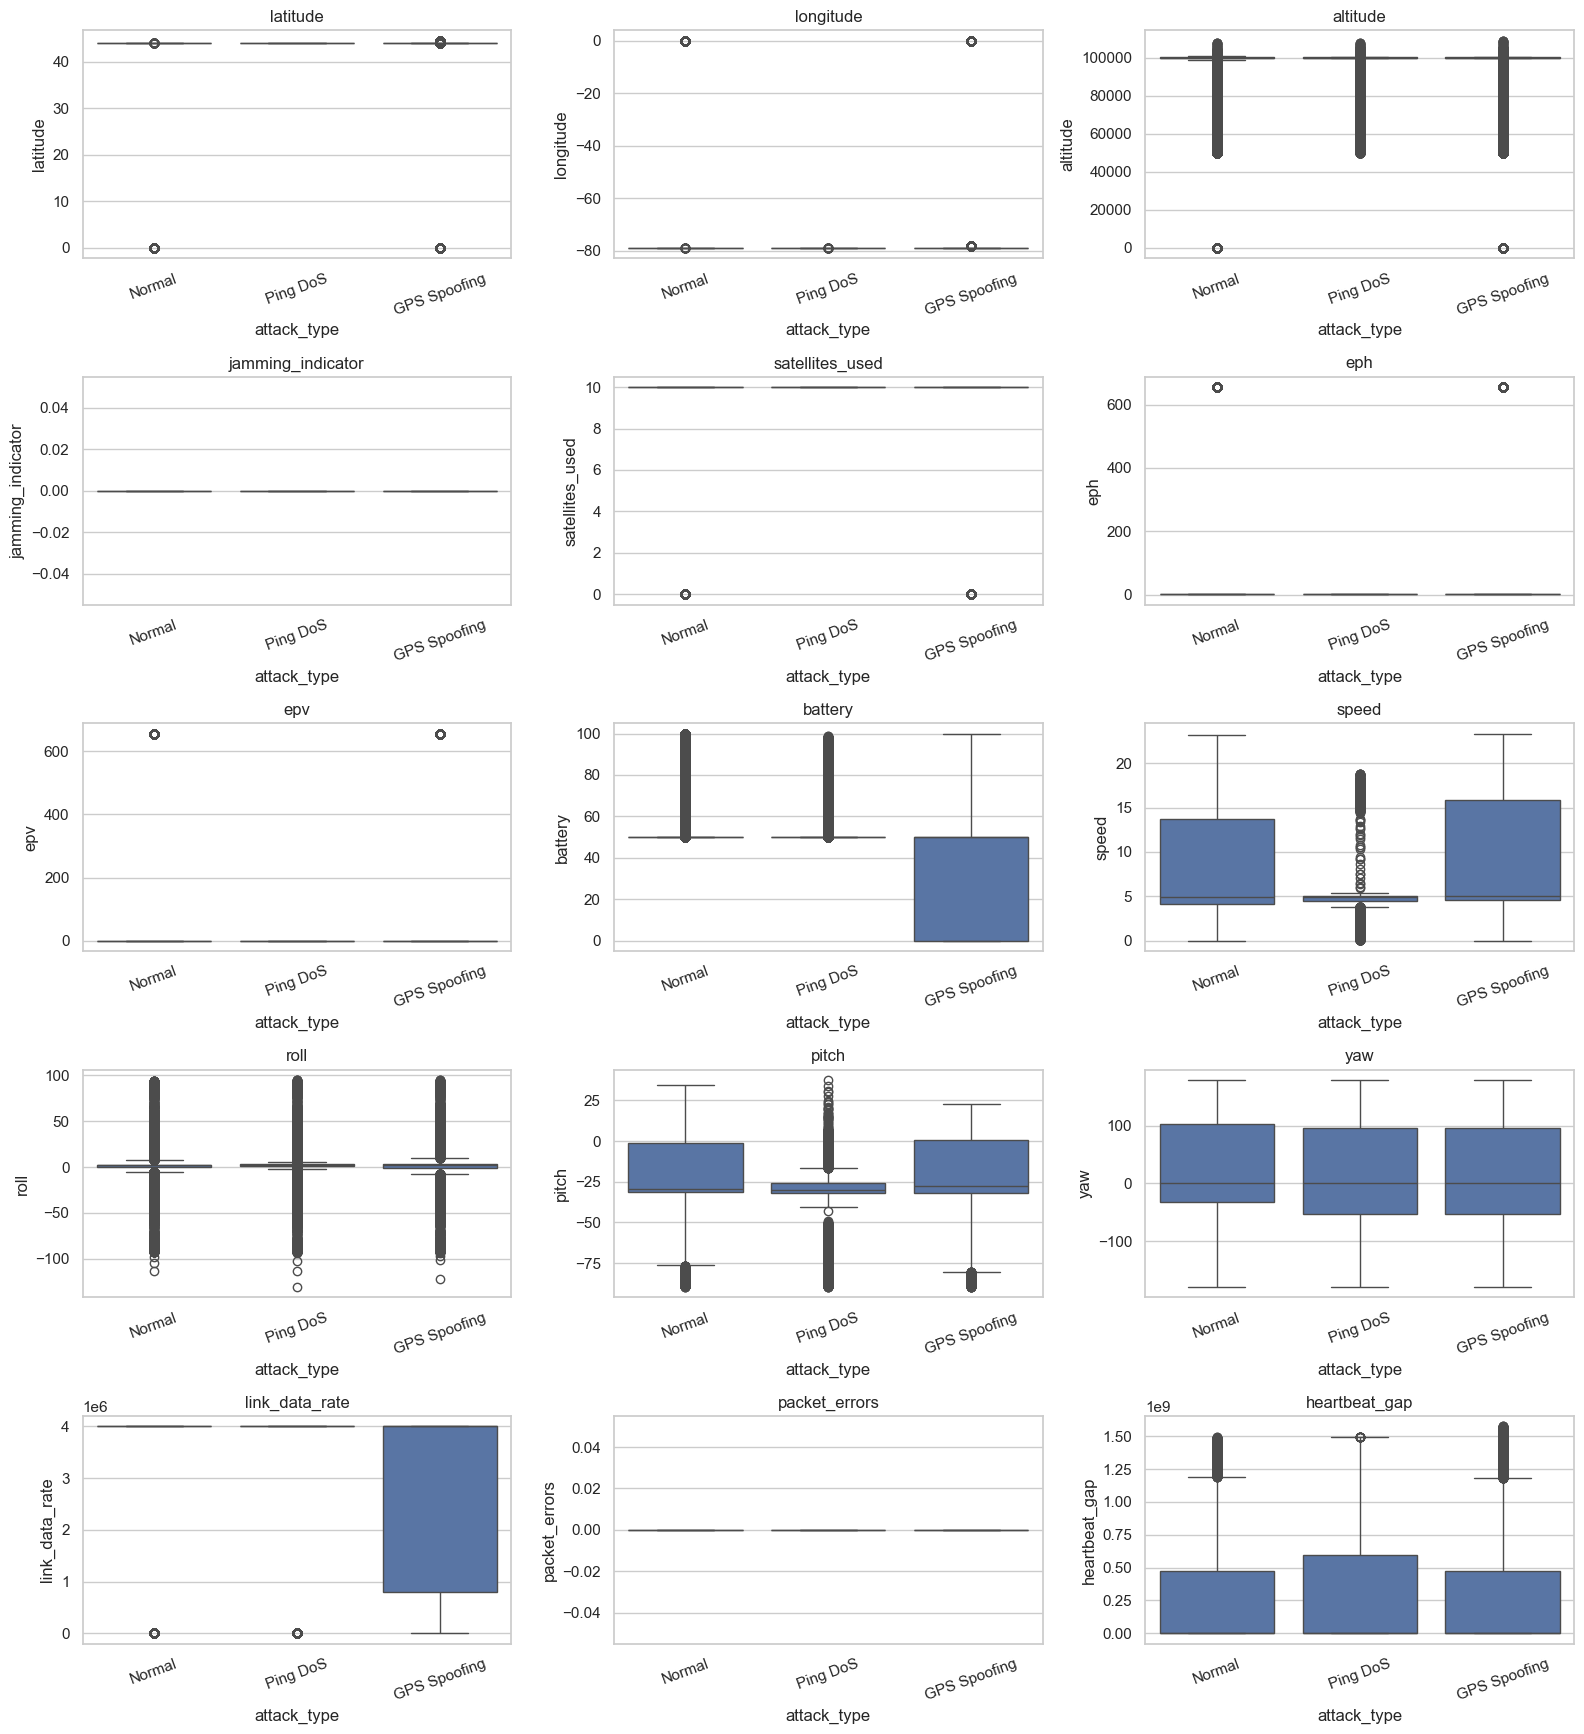

In [10]:
key_features = ["latitude", "longitude", "altitude", "jamming_indicator",
                 "satellites_used", "eph", "epv", "battery", "speed",
                 "roll", "pitch", "yaw", "link_data_rate", "packet_errors",
                 "heartbeat_gap"]
key_features = [c for c in key_features if c in df.columns]

ncols = 3
nrows = int(np.ceil(len(key_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x="attack_type", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=20)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 7. Correlation between numeric features

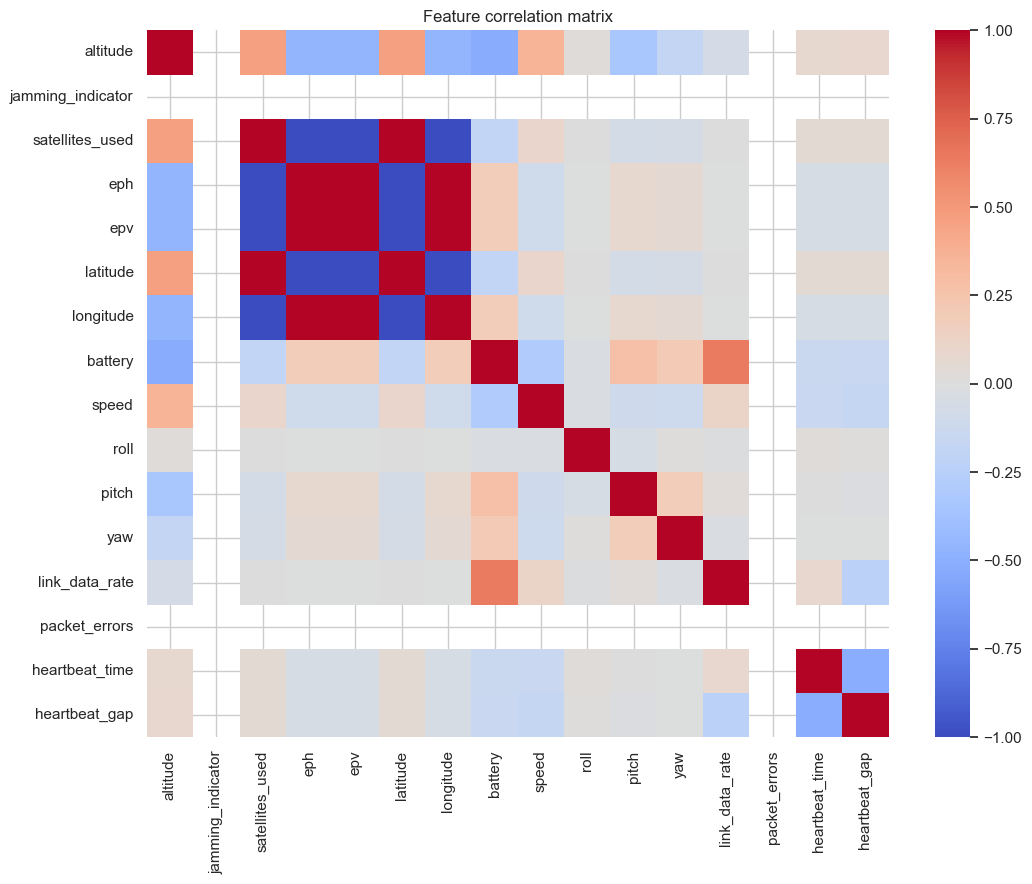

In [11]:
plt.figure(figsize=(11, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 8. GPS spoofing sanity check\n\nIf spoofing is working as expected, GPS Spoofing flights should show latitude/longitude jumps that Normal flights don't.

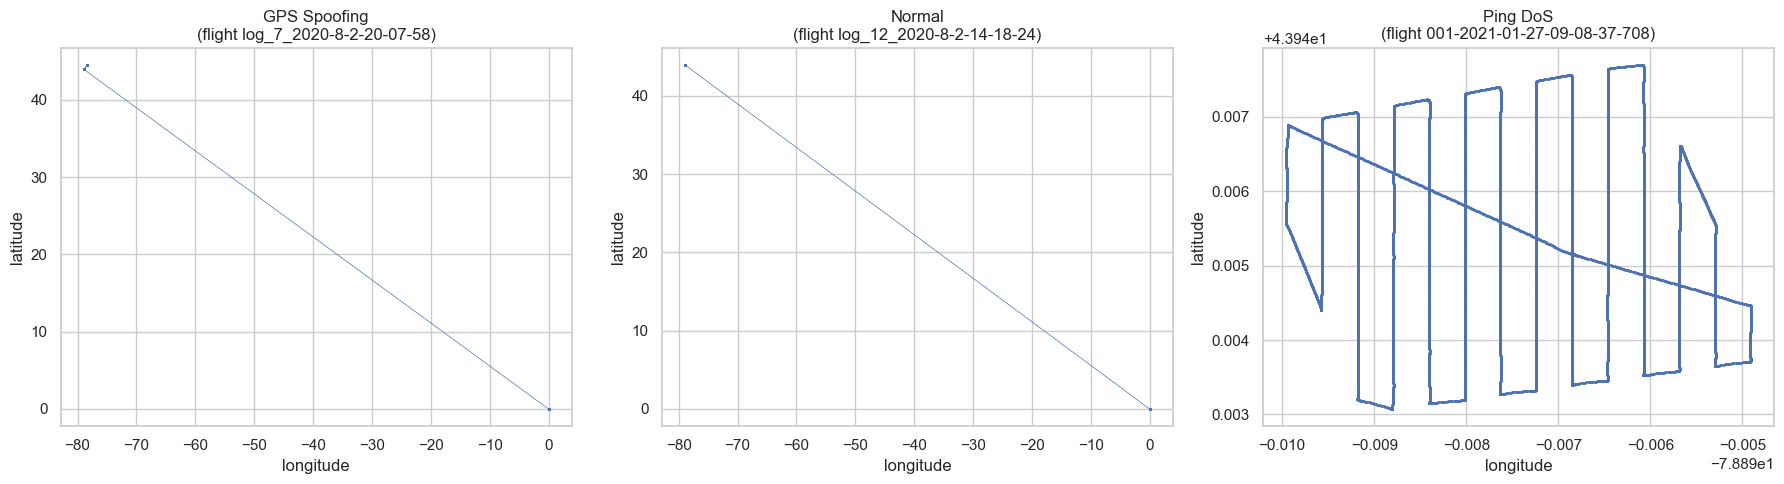

In [12]:
sample_flights = df.groupby("attack_type")["flight_id"].first()

fig, axes = plt.subplots(1, len(sample_flights), figsize=(6 * len(sample_flights), 5))
for ax, (attack, flight) in zip(axes, sample_flights.items()):
    sub = df[df["flight_id"] == flight].sort_values("timestamp")
    ax.plot(sub["longitude"], sub["latitude"], marker=".", markersize=2, linewidth=0.5)
    ax.set_title(f"{attack}\n(flight {flight})")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.tight_layout()
plt.show()

## 9. Summary\n\nFill in after running:\n- Missing values: ...\n- Duplicates: ...\n- Class balance: ...\n- Features with visible separation across attack types: ...\n- Features to drop / re-derive: ...